In [2]:
!pip install pandas

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Income            985 non-null    float64
 2   Loan_Amount       1000 non-null   int64  
 3   Credit_Score      1000 non-null   int64  
 4   Employment_Years  1000 non-null   int64  
 5   Education_Level   1000 non-null   object 
 6   Housing_Status    1000 non-null   object 
 7   Default           1000 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [7]:
df['Loan_Amount'].fillna(df['Loan_Amount'].median(), inplace=True)
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)
df['Employment_Years'].fillna(df['Employment_Years'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_21804\4191113496.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount'].fillna(df['Loan_Amount'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_21804\4191113496.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [8]:
le_education = LabelEncoder()
le_housing = LabelEncoder()

df['Education_Level'] = le_education.fit_transform(df['Education_Level'])
df['Housing_Status'] = le_housing.fit_transform(df['Housing_Status'])

In [9]:
print(df['Education_Level'].unique())
print(df['Housing_Status'].unique())

[0 3 2 1]
[1 2 0]


In [10]:
X = df[['Age','Income','Loan_Amount','Credit_Score',
        'Employment_Years','Education_Level','Housing_Status']]

y = df['Default']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
rs = RobustScaler()

X_train = rs.fit_transform(X_train)
X_test = rs.transform(X_test)

In [13]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [14]:
y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.525


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.53      0.66       172
           1       0.15      0.50      0.23        28

    accuracy                           0.53       200
   macro avg       0.51      0.51      0.44       200
weighted avg       0.77      0.53      0.60       200



In [16]:
sample = [[35,80000,10000,750,8,2,1]]

sample = rs.transform(sample)

print("Prediction:", lr.predict(sample))

Prediction: [1]


d:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


In [17]:
pickle.dump(lr, open("credit_model.pkl", "wb"))
pickle.dump(rs, open("scaler.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [18]:
pickle.dump(le_education, open("education_encoder.pkl","wb"))
pickle.dump(le_housing, open("housing_encoder.pkl","wb"))

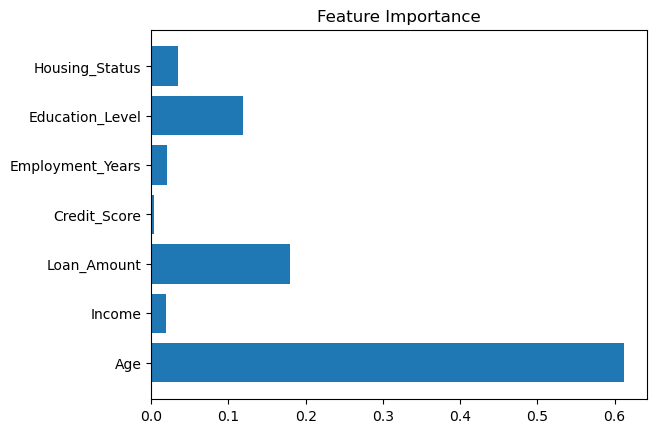

In [19]:
import matplotlib.pyplot as plt

importance = abs(lr.coef_[0])

features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       random_state=42)

In [21]:
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.855


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

print("Accuracy:", gb.score(X_test, y_test))

Accuracy: 0.855


In [23]:
import pickle

pickle.dump(rf, open("credit_model.pkl", "wb"))
pickle.dump(rs, open("scaler.pkl", "wb"))

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [25]:
import pandas as pd

importance = model.feature_importances_

features = X.columns

pd.DataFrame({
    "Feature":features,
    "Importance":importance
}).sort_values("Importance",ascending=False)

,Feature,Importance
0,Age,0.196192
2,Loan_Amount,0.193335
3,Credit_Score,0.193140
1,Income,0.164354
4,Employment_Years,0.150429
5,Education_Level,0.057075
6,Housing_Status,0.045475


In [26]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()

model.fit(X_train,y_train)

GradientBoostingClassifier()

In [27]:
import numpy as np

pred = model.predict(X_test)

print("0 count:", np.sum(pred==0))
print("1 count:", np.sum(pred==1))

0 count: 200
1 count: 0


In [ ]:
# new model train

In [28]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [29]:
df = pd.read_csv("credit_risk_dataset.csv")

In [30]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [31]:
from sklearn.preprocessing import LabelEncoder

le_education = LabelEncoder()
le_housing = LabelEncoder()

df['Education_Level'] = le_education.fit_transform(df['Education_Level'])
df['Housing_Status'] = le_housing.fit_transform(df['Housing_Status'])

In [32]:
X = df[['Age','Income','Loan_Amount','Credit_Score',
        'Employment_Years','Education_Level','Housing_Status']]

y = df['Default']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=400, random_state=42)

In [36]:
import numpy as np

pred = model.predict(X_test)

print("0 count:", np.sum(pred==0))
print("1 count:", np.sum(pred==1))

0 count: 179
1 count: 21


In [37]:
import pickle

pickle.dump(model, open("credit_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_split=5, n_estimators=500, random_state=42)

In [41]:
import numpy as np

pred = model.predict(X_test)

print("0 count:", np.sum(pred==0))
print("1 count:", np.sum(pred==1))

0 count: 189
1 count: 11


In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=5, n_estimators=300)

In [44]:
import numpy as np

pred = model.predict(X_test)

print("0 count:", np.sum(pred==0))
print("1 count:", np.sum(pred==1))

0 count: 186
1 count: 14


In [45]:
from imblearn.ensemble import BalancedRandomForestClassifier

model = BalancedRandomForestClassifier(
    n_estimators=400,
    random_state=42
)

model.fit(X_train, y_train)

BalancedRandomForestClassifier(n_estimators=400, random_state=42)

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89       172
           1       0.07      0.04      0.05        28

    accuracy                           0.80       200
   macro avg       0.46      0.48      0.47       200
weighted avg       0.75      0.80      0.77       200



In [47]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=6,   # IMPORTANT (imbalance fix)
    random_state=42
)

model.fit(X_train, y_train)

ModuleNotFoundError: No module named 'xgboost'

In [49]:
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [50]:
from imblearn.ensemble import BalancedRandomForestClassifier

model = BalancedRandomForestClassifier(
    n_estimators=500,
    random_state=42
)

model.fit(X_train, y_train)

BalancedRandomForestClassifier(n_estimators=500, random_state=42)